# **Introduction**
Seismic traces are the convolution of the Earth's reflectivity with a seismic wavelet, in addition with noise.
By applying deconvolution, the project aims to recover the reflectivity by removing the wavelet's imprint.
This notebook demonstratres:

*   Generation of synthetic seismic data.

*   Convolution of seismic data with reflectivity.




*   Applying Wiener deconvolution in frequency domain (Fourier transformation) to provide stable, regularized estimate of reflectivity




In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
#   Generating synthetic reflectivity series.
reflectivity = np.zeros(500)
reflectivity[[50, 120, 200, 300, 400]] = [0.8, -0.6, 0.7, -0.5, 0.9]

In [7]:
#   Ricker Wavelet- zero-phase wavelet

f = 25    #frequency
length = 0.2
dt = 0.002  #time step

t_wavelet = np.arange(-length/2, length/2, dt)
pi2 = (np.pi**2) * (f**2)
wavelet = (1 - 2*pi2*t_wavelet**2) * np.exp(-pi2*t_wavelet**2)

In [8]:
#  Convolution of reflectivity with wavelet
synthetic_trace = np.convolve(reflectivity, wavelet, mode='same')

In [9]:
#  Adding randomly generated noise
noise = np.random.normal(0, 0.05, synthetic_trace.shape)
synthetic_trace_noisy = synthetic_trace + noise

In [14]:
#  Wiener Deconvolution
def wiener_deconvolution(trace, wavelet, alpha):
    n = len(trace)
    nfft = 2*n

    # Fourier transformation to switch to Frequency domain
    S = np.fft.fft(trace, nfft)
    W = np.fft.fft(wavelet, nfft)

    # Wiener filter
    W_conj = np.conj(W)
    R = (S * W_conj) / (W * W_conj + alpha)

    # Switching back to time domain
    r_est = np.fft.ifft(R)
    return np.real(r_est[:n])

alpha = 0.01  # noise stabilization factor
wiener_trace = wiener_deconvolution(synthetic_trace_noisy, wavelet, alpha)


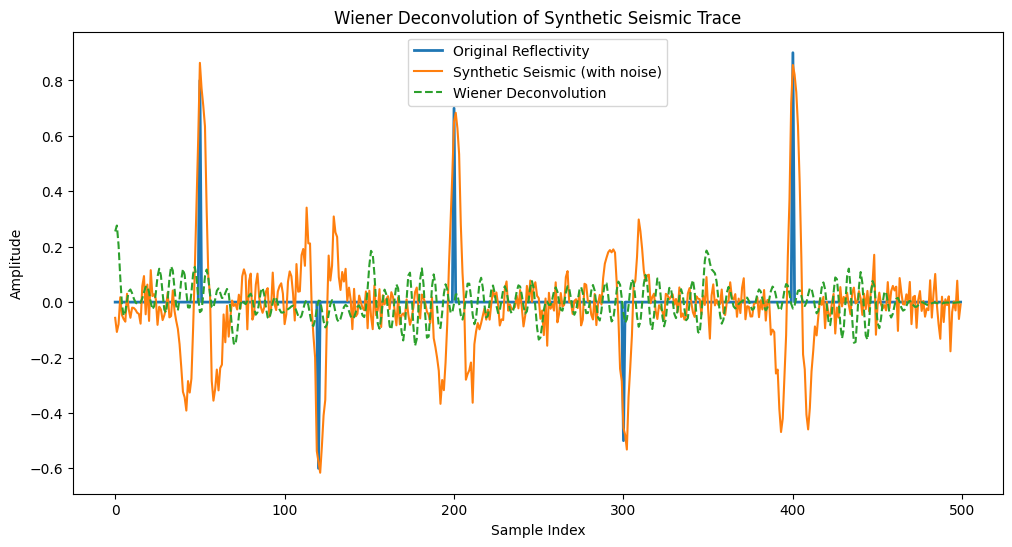

In [16]:
#  Plotting the results
plt.figure(figsize=(12,6))
plt.plot(reflectivity, label='Original Reflectivity', linewidth=2)
plt.plot(synthetic_trace_noisy, label='Synthetic Seismic (with noise)')
plt.plot(wiener_trace, label='Wiener Deconvolution', linestyle='--')
plt.title('Wiener Deconvolution of Synthetic Seismic Trace')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

The deconvolved trace recovers the spike-like events that correspond to true reflectivity, while filtering noise.

# **References**



*   **Yilmaz, Ö. (2001).** Seismic Data Analysis: Processing, Inversion, and Interpretation of Seismic Data. Society of Exploration Geophysicists. (Primary source for Wiener Deconvolution theory)

*   Shearer, P. M. (2009). Introduction to Seismology. Cambridge University Press. (Physics of Convolution)

*   https://wiki.seg.org/wiki/Dictionary:Ricker_wavelet




